In [100]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [101]:
df=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Desktop\python\diamonds.csv",index_col='Unnamed: 0')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [102]:
df.shape

(53940, 10)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [104]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [105]:
df=df[df.duplicated()==False]

In [106]:
cat_cols=[col for col in df.columns if df[col].dtype=='object']
num_cols=[col for col in df.columns if df[col].dtype!='object']

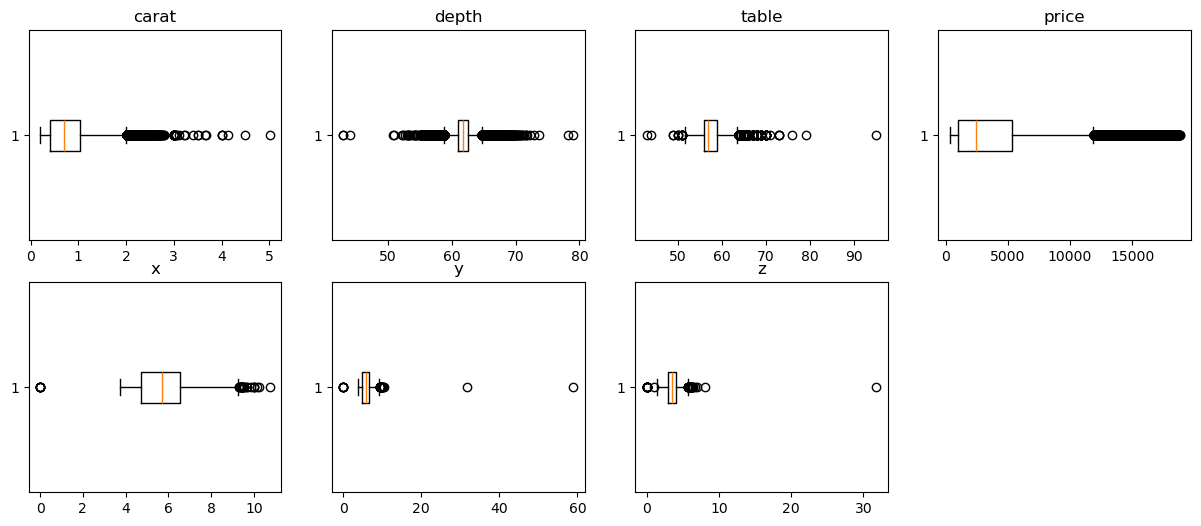

In [107]:
plt.figure(figsize=(15,6))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,4,i)
    plt.boxplot(df[col],vert=False)
    plt.title(col)
plt.show()

In [108]:
q1,q3=np.percentile(df['carat'],[25,75])
iqr=q3-q1
lower=q1-1.5 *iqr
upper=q3+1.5 * iqr
df=df[(df['carat']>=lower) & (df['carat']<=upper)]

In [109]:
df.shape

(51921, 10)

In [110]:
q1,q3=np.percentile(df['depth'],[25,75])
iqr=q3-q1
lower=q1-1.5 *iqr
upper=q3+1.5 * iqr
df=df[(df['depth']>=lower) & (df['depth']<=upper)]

In [111]:
df.shape

(49142, 10)

In [112]:
q1,q3=np.percentile(df['table'],[25,75])
iqr=q3-q1
lower=q1-1.5 *iqr
upper=q3+1.5 * iqr
df=df[(df['table']>=lower) & (df['table']<=upper)]

In [113]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [114]:
from sklearn.preprocessing import LabelEncoder

In [115]:
le=LabelEncoder()
for col in cat_cols:
   df.loc[:, col] = le.fit_transform(df[col])
df.head(n=10)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
2,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
4,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
5,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75
6,0.24,4,6,7,62.8,57.0,336,3.94,3.96,2.48
7,0.24,4,5,6,62.3,57.0,336,3.95,3.98,2.47
8,0.26,4,4,2,61.9,55.0,337,4.07,4.11,2.53
10,0.23,4,4,4,59.4,61.0,338,4.00,4.05,2.39
11,0.30,1,6,2,64.0,55.0,339,4.25,4.28,2.73
12,0.23,2,6,4,62.8,56.0,340,3.93,3.90,2.46


In [116]:
X=df.drop('price',axis=1)
y=df['price']

In [117]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [118]:
df.corr()

,carat,cut,color,clarity,depth,table,price,x,y,z
carat,1.000000,0.062851,0.234097,-0.183742,0.032239,0.180346,0.909094,0.983128,0.975998,0.959490
cut,0.062851,1.000000,0.009005,-0.007011,-0.161484,0.303079,0.048686,0.063377,0.064891,0.049113
color,0.234097,0.009005,1.000000,-0.012175,0.043840,0.018466,0.098595,0.217736,0.215817,0.215129
clarity,-0.183742,-0.007011,-0.012175,1.000000,-0.047796,-0.079644,-0.030619,-0.197312,-0.193687,-0.194549
depth,0.032239,-0.161484,0.043840,-0.047796,1.000000,-0.229039,-0.000707,-0.010813,-0.012506,0.084758
table,0.180346,0.303079,0.018466,-0.079644,-0.229039,1.000000,0.121265,0.181541,0.174565,0.151933
price,0.909094,0.048686,0.098595,-0.030619,-0.000707,0.121265,1.000000,0.872750,0.868305,0.850240
x,0.983128,0.063377,0.217736,-0.197312,-0.010813,0.181541,0.872750,1.000000,0.991348,0.971275
y,0.975998,0.064891,0.215817,-0.193687,-0.012506,0.174565,0.868305,0.991348,1.000000,0.965633
z,0.959490,0.049113,0.215129,-0.194549,0.084758,0.151933,0.850240,0.971275,0.965633,1.000000


<Axes: >

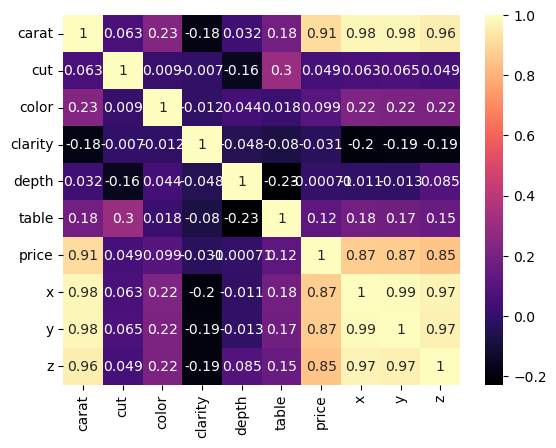

In [119]:
sns.heatmap(df.corr(),cmap='magma',annot=True)

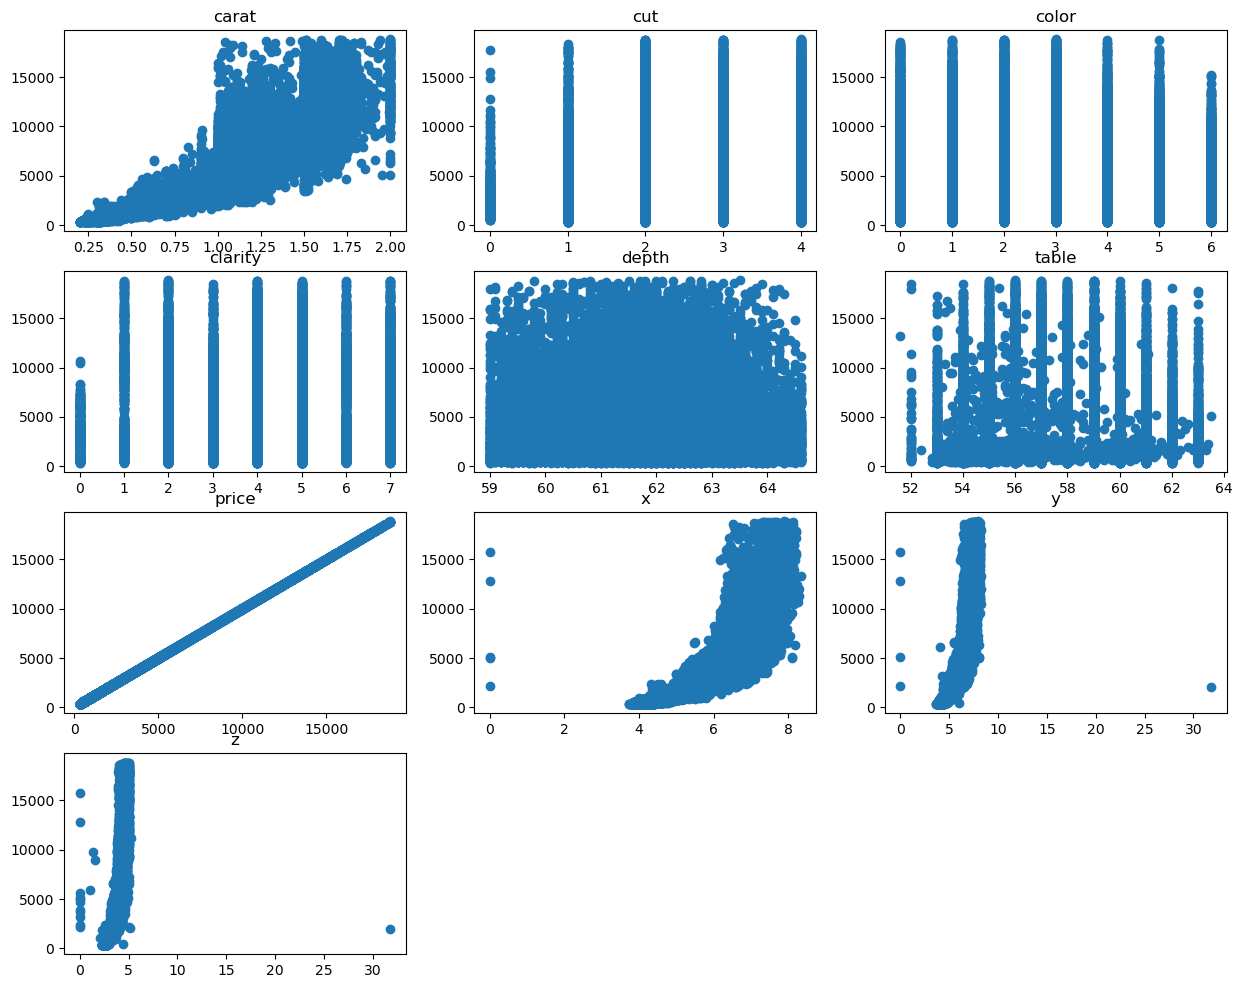

In [120]:
plt.figure(figsize=(15,12))
for i,col in enumerate(df.columns,1):
    plt.subplot(4,3,i)
    plt.scatter(df[col],df['price'])
    plt.title(col)
plt.show()

In [121]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [122]:
model=HistGradientBoostingRegressor(
    learning_rate=0.05, 
    min_samples_leaf=20,
    max_depth=6, 
    max_iter=500, 
    random_state=42
)
model.fit(X_train,y_train)




HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=500,
                              random_state=42)

In [123]:
y_pred=model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)
print("R2:",r2_score(y_test,y_pred))

MAE: 225.86326397515498
MSE: 182645.8189366931
RMSE: 427.3708213445241
R2: 0.9840651642379705


In [124]:
y_train_pred=model.predict(X_train)
print("Train:",r2_score(y_train,y_train_pred))
print("Test:",r2_score(y_test,y_pred))

Train: 0.988083790346783
Test: 0.9840651642379705


In [88]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)


In [89]:


importances = pd.Series(
    result.importances_mean,
    index=[f"feature_{i}" for i in range(X_test.shape[1])]
).sort_values(ascending=False)

print(importances.head(10))


feature_0    1.143728
feature_7    0.239254
feature_3    0.190135
feature_2    0.119379
feature_6    0.012084
feature_8    0.009209
feature_1    0.002061
feature_4    0.000658
feature_5    0.000199
dtype: float64


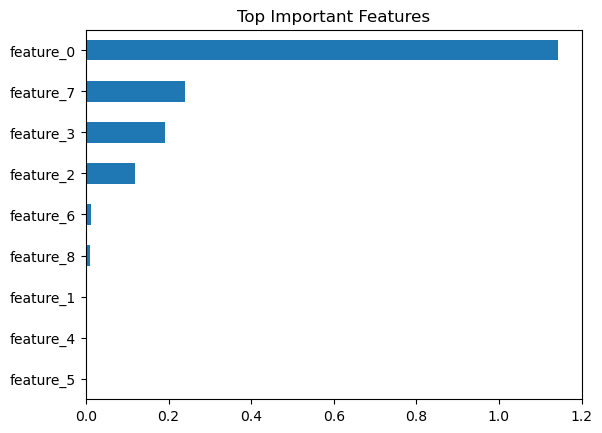

In [90]:
importances.head(10).plot.barh()
plt.gca().invert_yaxis()
plt.title("Top Important Features")
plt.show()


In [91]:
weak_features = importances.tail(3).index
print(weak_features)


Index(['feature_1', 'feature_4', 'feature_5'], dtype='object')


In [92]:
df=df.drop(['cut','clarity','depth'],axis=1)

In [93]:
df.shape

(48800, 7)

In [96]:
X=df.drop('price',axis=1)
y=df['price']

In [97]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model.fit(X_train,y_train)


HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=500,
                              random_state=42)

In [98]:
y_pred=model.predict(X_test)
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred)**0.5)
print("R2:",r2_score(y_test,y_pred))


MAE: 568.0883307059242
MSE: 1062455.496896924
RMSE: 1030.754819002523
R2: 0.907306644378287
